In [1]:
import ee
from rich.jupyter import display
from sympy.stats.sampling.sample_numpy import numpy

ee.Authenticate()

True

In [2]:
ee.Initialize(project="climateconsciousimli")  # assumes you've authenticated already

In [29]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt
import torch
import numpy as np

In [239]:
# Define bounding box (lon_min, lat_min, lon_max, lat_max)
lat_min, lat_max = 28.0, 29.39
lon_min, lon_max = 76.3, 79.0
roi = ee.Geometry.Rectangle([lon_min, lat_min, lon_max, lat_max])
pixel = ee.Geometry.Point([77.0, 29.0])
scale = 20000
start_date = '2024-02-07'
end_date = '2024-02-09'

- Everything is the same till now.
- `scale` is \~8km.
- `pixel` is one point.
- `roi` is the region.
- Now collect the data accordingly :

In [240]:
"""
Can define multiple collections (wind, SO2, NO2). Prepare what we're doing for each. Then feed outputs for all. No merging required as such, except right before training/input into a model.
"""

collection = (
    ee.ImageCollection("COPERNICUS/S5P/OFFL/L3_NO2")
    .filterBounds(roi)# REPLACE WITH ROI
    .filterDate(start_date, end_date)
    .select('tropospheric_NO2_column_number_density')
)

- The function `make_coarse` given below is of interest. In words (which I myself don't fully understand yet), it takes in raw data, reduces its resolution by taking a mean (how is that done/executed?). It then "reprojeccts" the data, with some scale in mind, giving us the "coarse" data.
- For now, it is not being used (?)

In [241]:
def make_coarse(image):
    return (image
        .reduceResolution(
            reducer=ee.Reducer.mean(),
            bestEffort=True
        )
        .reproject(
            crs='EPSG:4326',
            scale=1000
        )#.focal_mean(radius=2, units='pixels')
        .copyProperties(image, ['system:time_start'])
    )

coarse_collection = collection.map(make_coarse) # This (possibly coarse) collection will be henceforth be used.


print(f"Size of collection is {coarse_collection.size().getInfo()}. In particular, coarse_collection.getInfo()['features'] has that many items.")
print()

print(coarse_collection.first().getInfo()['properties']['system:time_start']) # need to parse as date-time

Size of collection is 28. In particular, coarse_collection.getInfo()['features'] has that many items.

1707269343000


In [242]:
def sample_image(image):
    samples = image.sample(
        region=roi,
        scale=scale,
        geometries=True,
        dropNulls=False
    )
    # return samples.map(lambda f: f.set('system:time_start', f.getInfo()['properties']['system:time_start'])).map(lambda f: f.set(
    #     'date', image.date().format('YYYY-MM-dd')
    # ))
    time_start = image.get('system:time_start')
    return samples.map(lambda f: f.set({
        # 'system:time_start': time_start,
        'date': ee.Date(time_start).format('YYYY-MM-dd'),
        'datetime': ee.Date(time_start).format('YYYY-MM-dd HH:mm:ss')
    }))

fc = coarse_collection.map(sample_image).flatten()

In [243]:
features = fc.getInfo()['features']
# print(f"Features are : \n\n{features}\n\n")
proppies = features[0]['properties'] # ['tropospheric_NO2_column_number_density'])
print(f"Following is 'fc.getInfo()['features'][0]['properties']' : \n\n{proppies}\n\n")
print()
print(f"proppies.get('tropospheric_NO2_column_number_density') gives {proppies.get('tropospheric_NO2_column_number_density')}")
print("This applies for proppies being the first record in the given time range. Now we will try them all out ....\n\n\n")

n_feature_instances = len(features)
print(n_feature_instances)
print(features[0].get('properties'))
for i in range(n_feature_instances):
    print(features[i]['properties'].get('tropospheric_NO2_column_number_density'), features[i]['properties'].get('datetime'))
# for j in proppies:
#     print(j)
#     print()

Following is 'fc.getInfo()['features'][0]['properties']' : 

{'date': '2024-02-07', 'datetime': '2024-02-07 01:29:03'}



proppies.get('tropospheric_NO2_column_number_density') gives None
This applies for proppies being the first record in the given time range. Now we will try them all out ....



3360
{'date': '2024-02-07', 'datetime': '2024-02-07 01:29:03'}
None 2024-02-07 01:29:03
None 2024-02-07 01:29:03
None 2024-02-07 01:29:03
None 2024-02-07 01:29:03
None 2024-02-07 01:29:03
None 2024-02-07 01:29:03
None 2024-02-07 01:29:03
None 2024-02-07 01:29:03
None 2024-02-07 01:29:03
None 2024-02-07 01:29:03
None 2024-02-07 01:29:03
None 2024-02-07 01:29:03
None 2024-02-07 01:29:03
None 2024-02-07 01:29:03
None 2024-02-07 01:29:03
None 2024-02-07 01:29:03
None 2024-02-07 01:29:03
None 2024-02-07 01:29:03
None 2024-02-07 01:29:03
None 2024-02-07 01:29:03
None 2024-02-07 01:29:03
None 2024-02-07 01:29:03
None 2024-02-07 01:29:03
None 2024-02-07 01:29:03
None 2024-02-07 01:29:03
None 2024-02-

In [244]:
features = fc.getInfo()['features']

rows = []
for f in features:
    props = f['properties']
    coords = f['geometry']['coordinates']

    if 'tropospheric_NO2_column_number_density' in props:
        rows.append({
            'lon': coords[0],
            'lat': coords[1],
            'date': props['date'],
            'datetime': props['datetime'],
            'NO2': props['tropospheric_NO2_column_number_density']
        })

df = pd.DataFrame(rows)
df

,lon,lat,date,datetime,NO2
0,76.626294,29.374910,2024-02-07,2024-02-07 06:33:33,0.000045
1,76.805957,29.374910,2024-02-07,2024-02-07 06:33:33,0.000040
2,76.985620,29.374910,2024-02-07,2024-02-07 06:33:33,0.000052
3,77.165283,29.374910,2024-02-07,2024-02-07 06:33:33,0.000047
4,77.344946,29.374910,2024-02-07,2024-02-07 06:33:33,0.000042
...,...,...,...,...,...
233,78.243261,28.117268,2024-02-08,2024-02-08 07:56:07,0.000051
234,78.422924,28.117268,2024-02-08,2024-02-08 07:56:07,0.000066
235,78.602587,28.117268,2024-02-08,2024-02-08 07:56:07,0.000050
236,78.782250,28.117268,2024-02-08,2024-02-08 07:56:07,0.000022


In [245]:
unique_dates = sorted(df['date'].unique())
print(len(df['date']))
selected_dates = unique_dates[:]

238


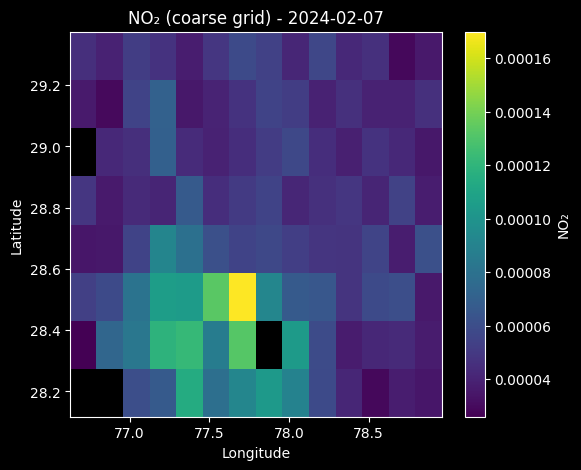

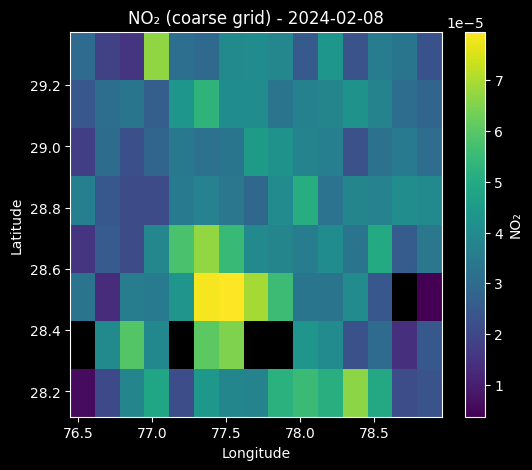

In [246]:
for d in selected_dates:
    subset = df[df['date'] == d]

    # Create grid
    pivot = subset.pivot_table(
        index='lat',
        columns='lon',
        values='NO2'
    )
    pivot.fillna(0)

    plt.figure(figsize=(6,5))
    plt.imshow(
        pivot.values,
        extent=(
            pivot.columns.min(), pivot.columns.max(),
            pivot.index.min(), pivot.index.max()
        ),
        origin='lower',
        aspect='auto'
    )
    plt.colorbar(label='NO₂')
    plt.title(f'NO₂ (coarse grid) - {d}')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.show()